In [150]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Oversupply by District and Sector

This notebook aims to identify the districts within cebu that **oversupply** the most for each of the target sectors: Construction, Hospitality, and Manufacturing.

#### Merging both files,

Based off code from `04_combining_supply_demand.ipynb`.

In [82]:
import pandas as pd

# Cebu demand (qualification-level, with District just carried through)
demand_df = pd.read_csv('cebu_demand.csv', index_col=0).reset_index()

demand_df['Program'] = demand_df['Program'].replace({
    'FOOD PRODUCTION (BREAD AND PATISSERIE) NC II': 'BREAD AND PASTRY PRODUCTION NC II'
})
demand_df['Sector'].replace(
    {'TOURISM (HOTEL AND RESTAURANT)': 'HOSPITALITY'},
    inplace=True
)

demand_df = demand_df.groupby(
    ['Program', 'Sector', 'District'], as_index=False
).agg({
    'Worst Demand': 'sum',
    'Base Demand':  'sum',
    'Best Demand':  'sum'
})

# Cebu supply (qualification-level, no districts yet)
supply_df = pd.read_csv('cebu_supply.csv', index_col=0).reset_index()
supply_df = supply_df.groupby('Qualification', as_index=False)['Graduates'].sum()
supply_df['Qualification'] = supply_df['Qualification'].str.upper()

# Merge to get Cebu qualification-level market
cebu_market_df = pd.merge(
    supply_df,
    demand_df,
    left_on='Qualification',
    right_on='Program',
    how='left'
)

cebu_market_df = cebu_market_df[
    ['Qualification', 'Sector', 'Worst Demand', 'Base Demand', 'Best Demand', 'Graduates']
].dropna()

# Bohol qualification market (already has expected totals)
bohol_cols = ['Qualification', 'Sector',
              'Worst_Expected_Total', 'Base_Expected_Total',
              'Best_Expected_Total', 'Graduates']

bohol_market_df = pd.read_csv('bohol_supply_gap_final.csv')[bohol_cols].rename(
    columns={
        'Worst_Expected_Total': 'Worst Demand',
        'Base_Expected_Total':  'Base Demand',
        'Best_Expected_Total':  'Best Demand'
    }
)

# Combine Region VII and build qualification_df for Sector mapping
region_vii_market_df = pd.concat([cebu_market_df, bohol_market_df], ignore_index=True)

qualification_df = region_vii_market_df.groupby('Qualification', as_index=False).agg({
    'Sector':        'first',
    'Worst Demand':  'sum',
    'Base Demand':   'sum',
    'Best Demand':   'sum',
    'Graduates':     'sum'
})

qualification_df['Worst Supply Gap'] = qualification_df['Worst Demand'] - qualification_df['Graduates']
qualification_df['Base Supply Gap']  = qualification_df['Base Demand']  - qualification_df['Graduates']
qualification_df['Best Supply Gap']  = qualification_df['Best Demand']  - qualification_df['Graduates']

# District mapping for NON–Cebu City

city_to_district = {
    "Lapu-Lapu City (Opon)": "Lapu-Lapu City, Lone District",
    "City of Talisay": "Cebu, District 1",
    "Minglanilla": "Cebu, District 1",
    "City of Naga": "Cebu, District 1",
    "San Fernando": "Cebu, District 1",
    "Argao": "Cebu, District 2",
    "Dalaguete": "Cebu, District 2",
    "Dumanjug": "Cebu, District 2",
    "Samboan": "Cebu, District 2",
    "Toledo City": "Cebu, District 3",
    "Balamban": "Cebu, District 3",
    "Asturias": "Cebu, District 3",
    "Danao City": "Cebu, District 4",
    "Carmen": "Cebu, District 4",
    "Compostela": "Cebu, District 4",
    "City of Bogo": "Cebu, District 5",
    "Daanbantayan": "Cebu, District 5",
    "Liloan": "Cebu, District 6",
    "Cordoba": "Cebu, District 6",
    "Mandaue City": "Cebu, District 7",
}

def infer_district(row):
    city = row["City Name"]

    # All Cebu City entries collapse into one bucket
    if city == "Cebu City":
        return "Cebu City (All Districts)"

    # Non–Cebu City
    return city_to_district.get(city, None)


# Load raw Cebu supply WITH city and infer District
cebu_supply = pd.read_csv("cebu_supply.csv", index_col=0).reset_index()
cebu_supply.columns = cebu_supply.columns.str.strip()
cebu_supply["Qualification"] = cebu_supply["Qualification"].str.upper()

cebu_supply["District"] = cebu_supply.apply(infer_district, axis=1)


# Attach Sector via qualification_df
qual_sector_map = qualification_df[["Qualification", "Sector"]].copy()
qual_sector_map["Qualification"] = qual_sector_map["Qualification"].str.upper()

cebu_supply = cebu_supply.merge(
    qual_sector_map,
    on="Qualification",
    how="left"
)

# =======================
# A. Supply per NC per district (District x Qualification x Sector)
# =======================
cebu_supply_nc = (
    cebu_supply
    .groupby(["District", "Qualification", "Sector"], as_index=False)
    .agg({"Graduates": "sum"})
)

# =======================
# B. Demand per NC per district (District x Program/Qualification x Sector)
# =======================

# Start from the already-grouped demand_df (Program, Sector, District, Worst/Base/Best)
demand_nc = demand_df.copy()

# Collapse Cebu City 1 / 2 / 1-2 into one bucket
demand_nc["District"] = demand_nc["District"].replace({
    "Cebu City, District 1":  "Cebu City (All Districts)",
    "Cebu City, District 2":  "Cebu City (All Districts)",
    "Cebu City, District 1/2": "Cebu City (All Districts)",
})

# Regroup in case collapsing created duplicates
demand_nc = (
    demand_nc
    .groupby(["District", "Program", "Sector"], as_index=False)
    .agg({
        "Worst Demand": "sum",
        "Base Demand":  "sum",
        "Best Demand":  "sum"
    })
)

# Rename Program -> Qualification to match supply side
demand_nc = demand_nc.rename(columns={"Program": "Qualification"})

# =======================
# C. Final NC-level district market table
# =======================

cebu_district_nc_market = (
    pd.merge(
        cebu_supply_nc,
        demand_nc,
        on=["District", "Qualification", "Sector"],
        how="left"
    )
    .fillna(0)
)
# columns:
# ['District', 'Qualification', 'Sector',
#  'Graduates', 'Worst Demand', 'Base Demand', 'Best Demand']

# =======================
# D. Aggregate to District x Sector (your old table)
# =======================

# Aggregate supply by District + Sector
supply_district = (
    cebu_supply.groupby(["District", "Sector"], as_index=False)
    .agg({"Graduates": "sum"})
)

# Demand by District + Sector
demand_raw = pd.read_csv("cebu_demand.csv", index_col=0).reset_index()
demand_raw["Sector"].replace(
    {'TOURISM (HOTEL AND RESTAURANT)': 'HOSPITALITY'},
    inplace=True
)

# Collapse Cebu City demand variants into one bucket BEFORE grouping
demand_raw["District"] = demand_raw["District"].replace({
    "Cebu City, District 1":  "Cebu City (All Districts)",
    "Cebu City, District 2":  "Cebu City (All Districts)",
    "Cebu City, District 1/2": "Cebu City (All Districts)",
})

demand_district = (
    demand_raw.groupby(["District", "Sector"], as_index=False)
    .agg({
        "Worst Demand": "sum",
        "Base Demand":  "sum",
        "Best Demand":  "sum"
    })
)

# Final Cebu district market table (sector-level)
cebu_district_market = (
    pd.merge(
        supply_district,
        demand_district,
        on=["District", "Sector"],
        how="outer"
    )
    .fillna(0)
)

cebu_district_market_collapsed = cebu_district_market.copy()


C:\Users\Raymond\AppData\Local\Temp\ipykernel_19680\802467265.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  demand_df['Sector'].replace(
C:\Users\Raymond\AppData\Local\Temp\ipykernel_19680\802467265.py:188: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing

#### Setting up a function for the graphs

In [172]:
def plot_district_supply_demand_by_nc(
    df,
    district,
    sector=None,              # e.g. "CONSTRUCTION", "HOSPITALITY", "MANUFACTURING", or None for all
    demand_col="Base Demand",
    title_prefix="Cebu"
):
    """
    df       : cebu_district_nc_market
    district : e.g. "Cebu City (All Districts)", "Cebu, District 1"
    sector   : optional sector filter; if None, shows all sectors' NCs
    """

    dist_df = df[df["District"] == district].copy()
    if dist_df.empty:
        print(f"No rows found for district = {district}")
        return

    if sector is not None:
        dist_df = dist_df[dist_df["Sector"] == sector].copy()
        if dist_df.empty:
            print(f"No rows for district = {district} and sector = {sector}")
            return

    # Sort NCs by supply gap (same idea as your other plot)
    if demand_col in dist_df.columns:
        dist_df["Supply Gap"] = dist_df["Graduates"] - dist_df[demand_col]
        dist_df = dist_df.sort_values("Supply Gap")
    else:
        dist_df = dist_df.sort_values(demand_col, ascending=False)

    quals  = dist_df["Qualification"].tolist()
    grads  = dist_df["Graduates"].values
    demand = dist_df[demand_col].values

    x = np.arange(len(quals))
    width = 0.35  # match your reference plot

    fig, ax = plt.subplots(figsize=(12, 6))

    # Graduates (left bar)
    ax.bar(x - width/2, grads,  width, label="Graduates",  color="#C22328")

    # Demand (right bar)
    ax.bar(x + width/2, demand, width, label=demand_col,   color="#f3a161")

    # Formatting to match your sample
    ax.set_ylabel("Count")
    ax.set_xticks(x)
    ax.set_xticklabels(quals, rotation=60, ha="right")
    ax.legend()

    # Hide top/right spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Title (you can comment out if you don’t want it)
    # title = f"{title_prefix} – {district}\nGraduates vs {demand_col} by NC"
    # if sector is not None:
    #     title += f" ({sector})"
    # ax.set_title(title)

    plt.tight_layout()
    plt.show()

    return fig, ax


# CEBU
*Graduates vs Base Demand by district* for each of the three main sectors (hospitality, manufacturing, and construction)

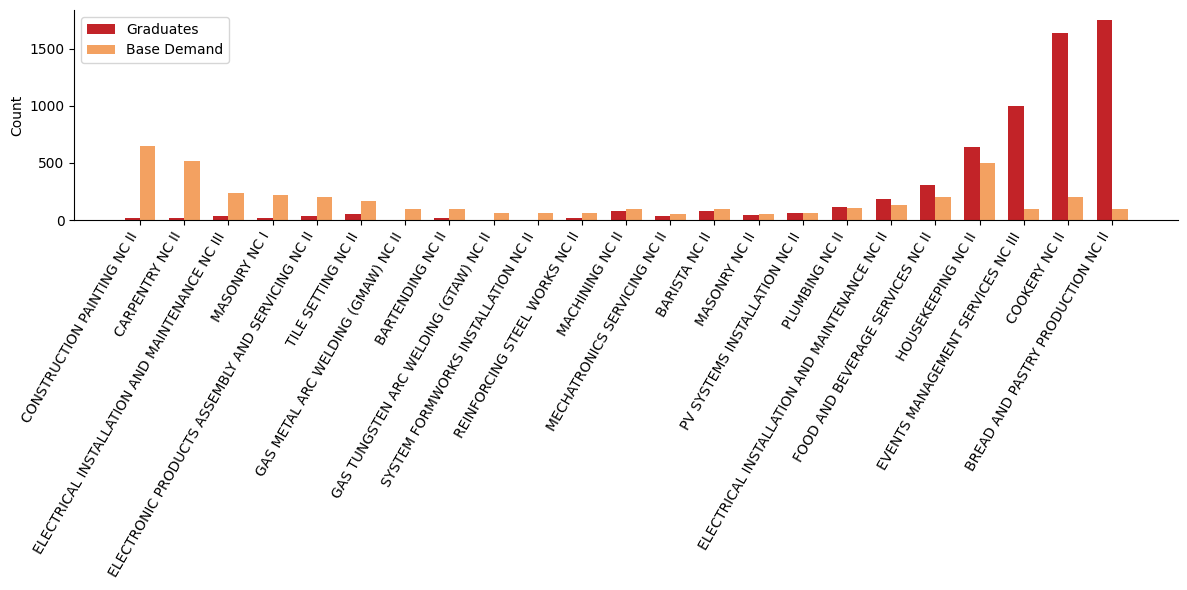

(<Figure size 1200x600 with 1 Axes>, <Axes: ylabel='Count'>)

In [173]:
plot_district_supply_demand_by_nc(
    df=cebu_district_nc_market,
    district="Cebu City (All Districts)"
)


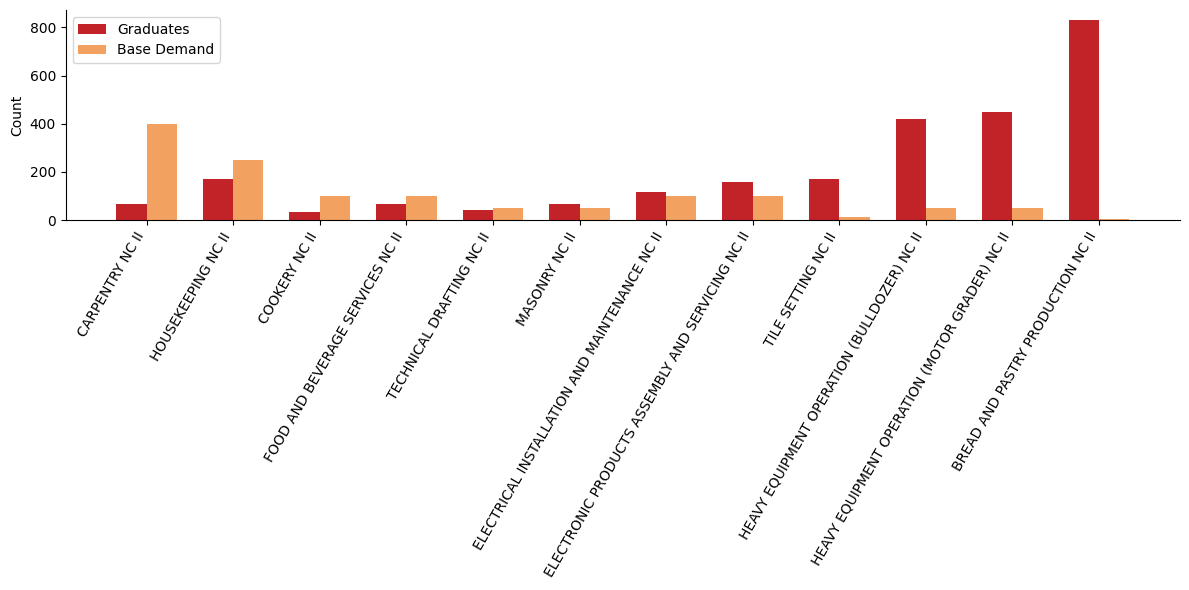

(<Figure size 1200x600 with 1 Axes>, <Axes: ylabel='Count'>)

In [174]:
plot_district_supply_demand_by_nc(
    df=cebu_district_nc_market,
    district="Cebu, District 1"
)


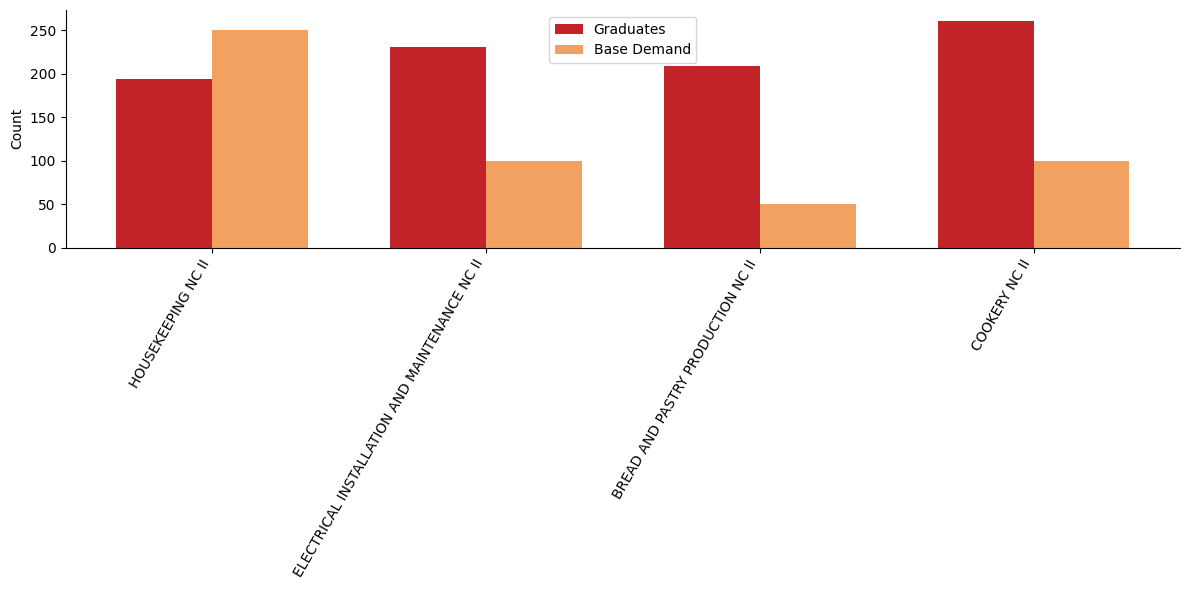

(<Figure size 1200x600 with 1 Axes>, <Axes: ylabel='Count'>)

In [175]:
plot_district_supply_demand_by_nc(
    df=cebu_district_nc_market,
    district="Cebu, District 2"
)

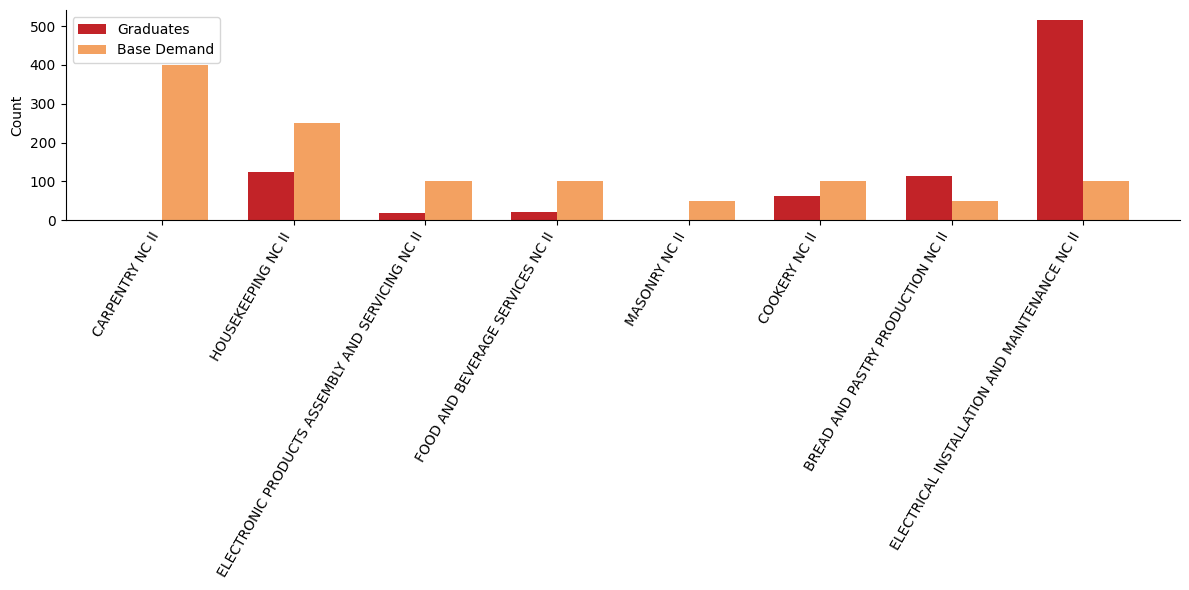

(<Figure size 1200x600 with 1 Axes>, <Axes: ylabel='Count'>)

In [176]:
plot_district_supply_demand_by_nc(
    df=cebu_district_nc_market,
    district="Cebu, District 3"
)


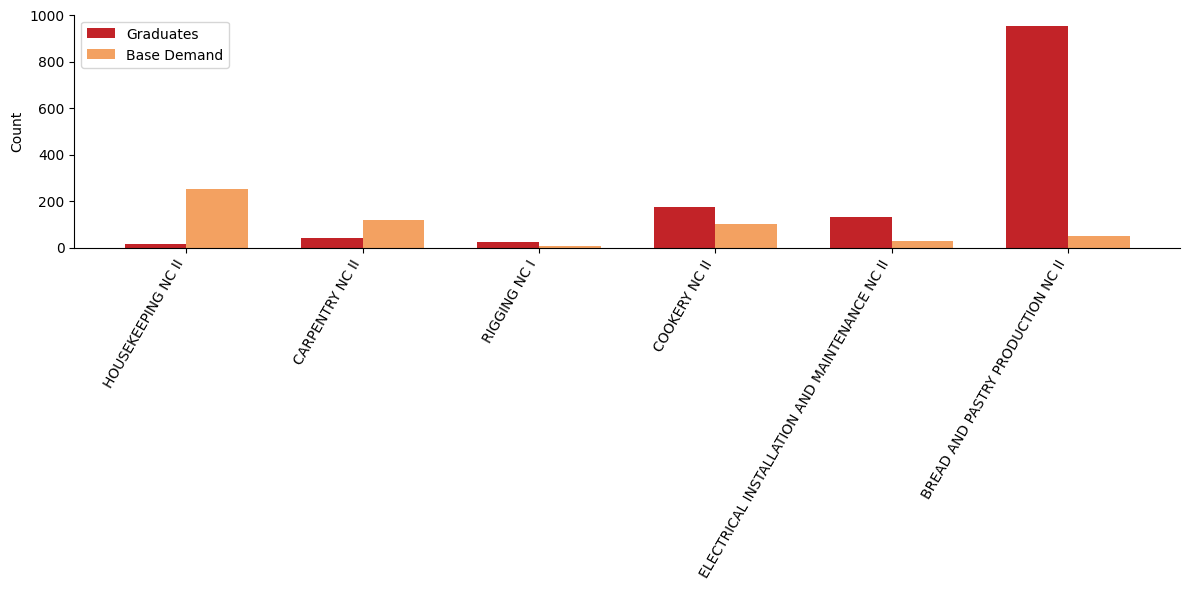

(<Figure size 1200x600 with 1 Axes>, <Axes: ylabel='Count'>)

In [177]:
plot_district_supply_demand_by_nc(
    df=cebu_district_nc_market,
    district="Cebu, District 4"
)


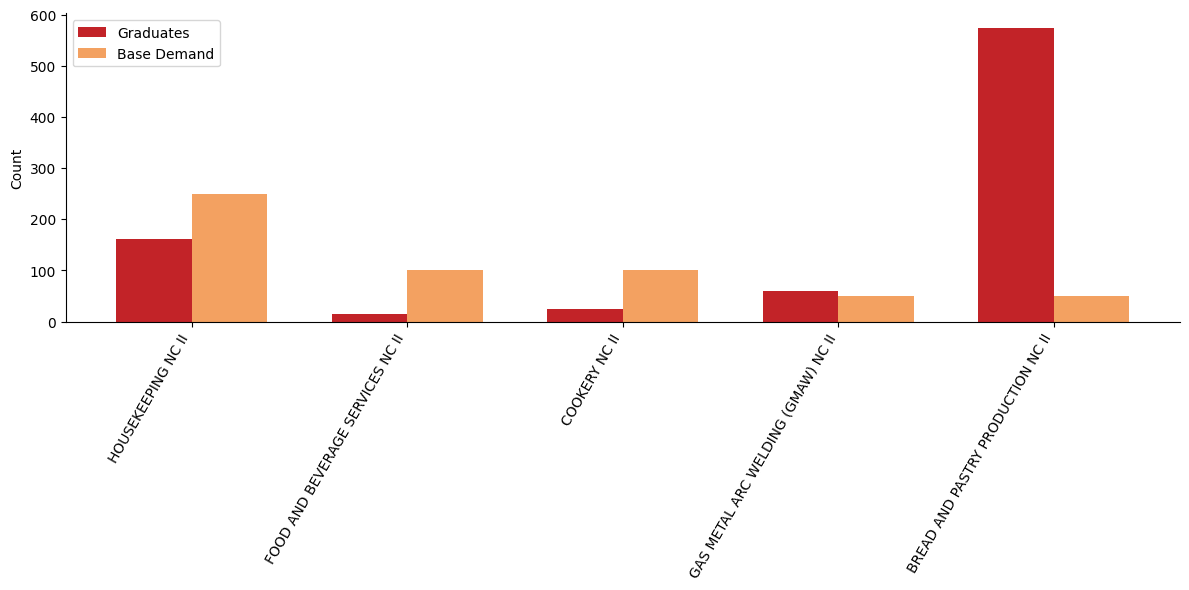

(<Figure size 1200x600 with 1 Axes>, <Axes: ylabel='Count'>)

In [178]:
plot_district_supply_demand_by_nc(
    df=cebu_district_nc_market,
    district="Cebu, District 5"
)


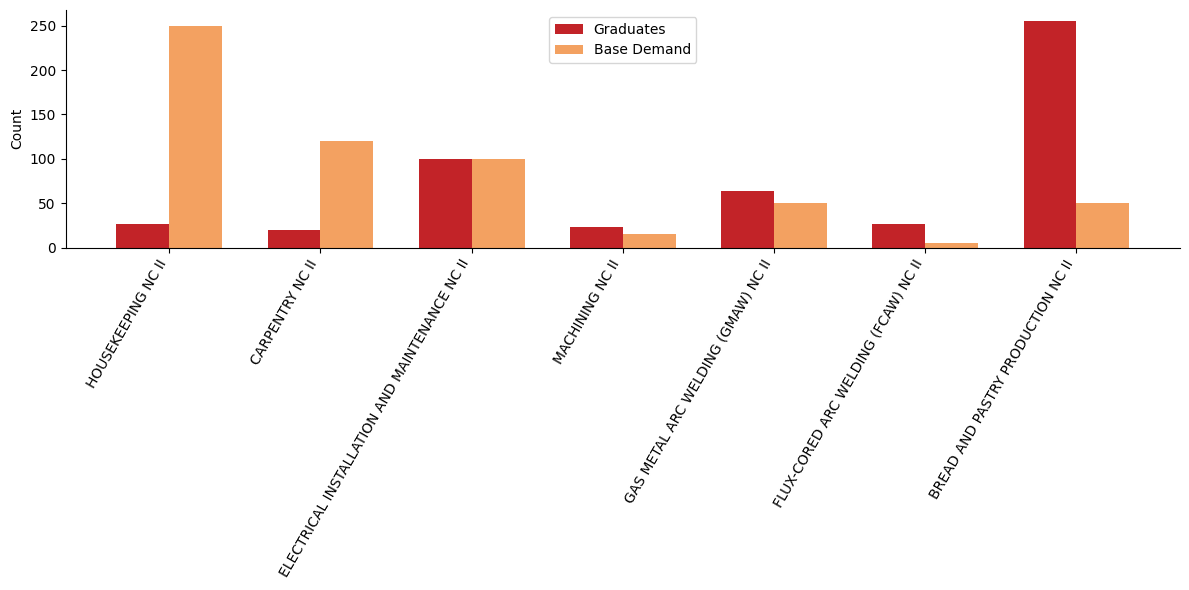

(<Figure size 1200x600 with 1 Axes>, <Axes: ylabel='Count'>)

In [179]:
plot_district_supply_demand_by_nc(
    df=cebu_district_nc_market,
    district="Cebu, District 6"
)


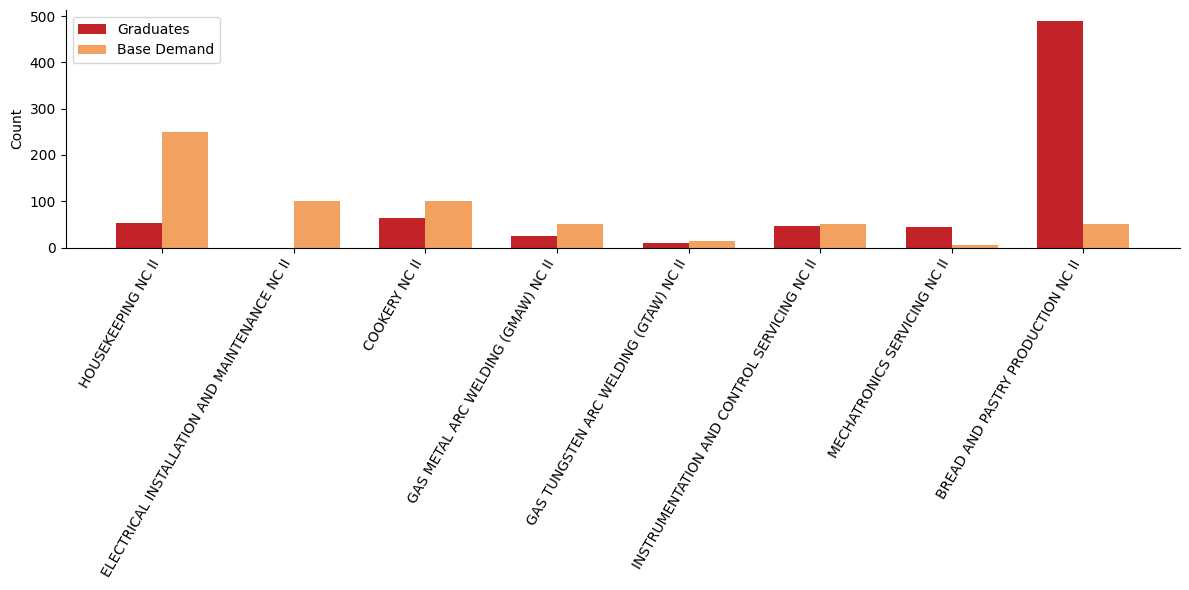

(<Figure size 1200x600 with 1 Axes>, <Axes: ylabel='Count'>)

In [180]:
plot_district_supply_demand_by_nc(
    df=cebu_district_nc_market,
    district="Cebu, District 7"
)


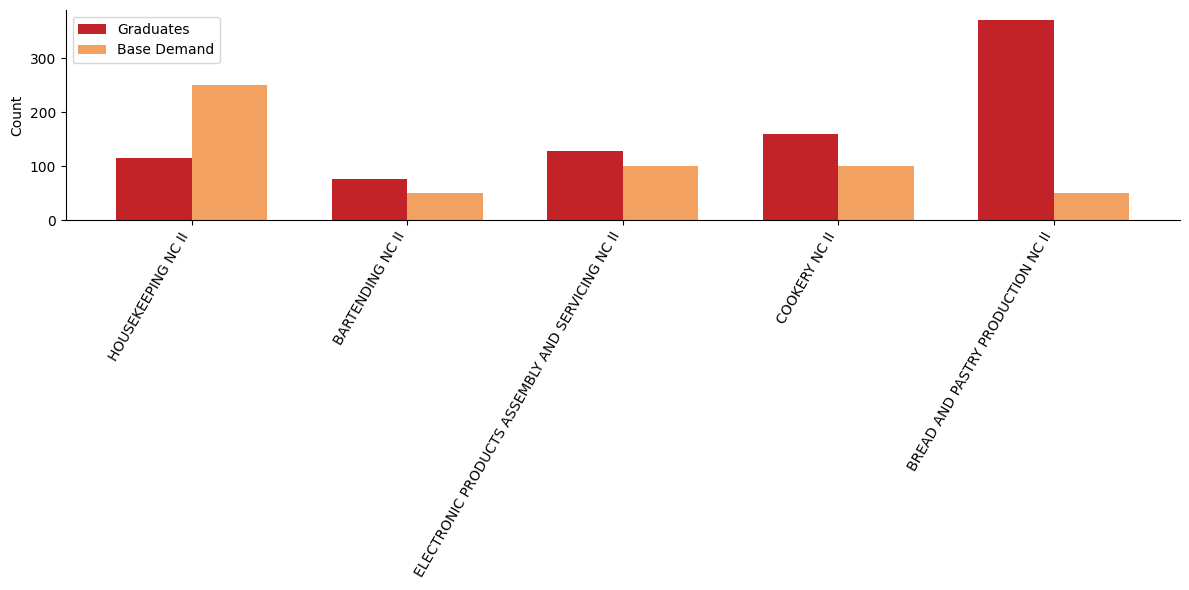

(<Figure size 1200x600 with 1 Axes>, <Axes: ylabel='Count'>)

In [181]:
plot_district_supply_demand_by_nc(
    df=cebu_district_nc_market,
    district="Lapu-Lapu City, Lone District"
)


##

# BOHOL 
*Graduates vs Base Demand by district* for each of the three main sectors (hospitality, manufacturing, and construction)

## Setup

In [ ]:
df = pd.read_excel('data/TESDA 2024 EGAC.xlsx', sheet_name='EG 2024')
df2 = pd.read_csv('bohol_supply_gap_final.csv')

bohol_districts = {
    "District 1": [
        "Alburquerque","Baclayon","Balilihan","Calape","Catigbian",
        "Cortes","Dauis","Loon","Maribojoc","Panglao","Sikatuna",
        "Tagbilaran City","Tubigon"
    ],
    "District 2": [
        "Bien Unido","Buenavista","Clarin","Getafe","Inabanga",
        "Sagbayan","San Isidro","Talibon","Trinidad","Ubay"
    ],
    "District 3": [
        "Alicia","Anda","Antequera","Batuan","Bilar","Carmen",
        "Dagohoy","Danao","Dimiao","Duero","Garcia Hernandez",
        "Guindulman","Jagna","Lila","Loay","Loboc","Mabini",
        "Pilar","Sevilla","Sierra Bullones","Valencia"
    ]
}

municipality_to_district = {
    mun: district
    for district, municipalities in bohol_districts.items()
    for mun in municipalities
}

# Bohol rows ONLY, as a real copy 
df_bohol = df[df['Province Name'] == 'Bohol'].copy()

# Clean city names
df_bohol['City_clean'] = (
    df_bohol['City Name']
    .astype(str)
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)
df_bohol['District'] = df_bohol['City_clean'].map(municipality_to_district)

# Clean qualification names in BOTH tables (common key)
df_bohol['Qual_key'] = df_bohol['Qualification'].astype(str).str.strip().str.upper()
df2['Qual_key']      = df2['Qualification'].astype(str).str.strip().str.upper()

print("Unmapped cities:", df_bohol[df_bohol['District'].isna()]['City_clean'].unique())

# Graduates by District x Qualification
grad_qual_district = (
    df_bohol.groupby(['District', 'Qual_key'])['Graduates']
    .sum()
    .reset_index()
)

# MERGE WITH SUPPLY-GAP TABLE 
df2_district = df2.merge(
    grad_qual_district,
    how='left',
    on='Qual_key'
)

# One Graduates column: prefer district, fallback to original
df2_district['Graduates_final'] = df2_district['Graduates_y'].fillna(df2_district['Graduates_x'])
df2_district = df2_district.drop(columns=['Graduates_x', 'Graduates_y'])
df2_district = df2_district.rename(columns={'Graduates_final': 'Graduates'})

# District-level supply gaps
df2_district['Best_Supply_Gap_District']  = df2_district['Best_Expected_Total']  - df2_district['Graduates']
df2_district['Base_Supply_Gap_District']  = df2_district['Base_Expected_Total']  - df2_district['Graduates']
df2_district['Worst_Supply_Gap_District'] = df2_district['Worst_Expected_Total'] - df2_district['Graduates']

Unmapped cities: []


No need for *province-level supply gaps* at this point, the *district-level supply gaps* should be enough.

In [144]:
df2_district = df2_district.drop(columns=[
    'Best_Supply_Gap',
    'Base_Supply_Gap',
    'Worst_Supply_Gap'
])

In [ ]:
sorted(df2_district['District'].dropna().unique())

['District 1', 'District 2', 'District 3']

This code filters the dataset to show all rows where District is NaN, meaning the qualification has no recorded graduates in any district in Bohol. It then prints only the Qualification name and the number of Graduates, letting you quickly see which NCs have zero supply in the province. Basically, this was a sanity check for the **NaN** values under the *district* column in the dataframe.

In [145]:
missing = df2_district[df2_district['District'].isna()][['Qualification', 'Graduates']]
print(missing)

                                       Qualification  Graduates
3                      PV SYSTEMS INSTALLATION NC II        0.0
4   HEAVY EQUIPMENT OPERATION (CRAWLER CRANE) NC III        0.0
5   ELECTRONIC PRODUCTS ASSEMBLY AND SERVICING NC II        0.0
6                       PIPEFITTING (METALLIC) NC II        0.0
7                                     PLUMBING NC II        0.0
8                SYSTEM FORMWORKS INSTALLATION NC II        0.0
9    HEAVY EQUIPMENT OPERATION (TRANSIT MIXER) NC II        0.0
16     ELECTRICAL INSTALLATION AND MAINTENANCE NC IV        0.0
19                                    PLUMBING NC II        0.0
23                       FRONT OFFICE SERVICES NC II        0.0
24                GAS METAL ARC WELDING (GMAW) NC II        0.0
25               FLUX-CORED ARC WELDING (FCAW) NC II        0.0
26                       TOUR GUIDING SERVICES NC II        0.0
28                             TRAVEL SERVICES NC II        0.0


In [182]:
df2_district

,Qualification,Best_Expected_Total,Base_Expected_Total,Worst_Expected_Total,Sector,Qual_key,District,Graduates,Best_Supply_Gap_District,Base_Supply_Gap_District,Worst_Supply_Gap_District
0,MASONRY NC I,600.0,300.0,180.0,CONSTRUCTION,MASONRY NC I,District 1,22.0,578.0,278.0,158.0
1,MASONRY NC I,600.0,300.0,180.0,CONSTRUCTION,MASONRY NC I,District 2,27.0,573.0,273.0,153.0
2,MASONRY NC I,600.0,300.0,180.0,CONSTRUCTION,MASONRY NC I,District 3,25.0,575.0,275.0,155.0
3,PV SYSTEMS INSTALLATION NC II,330.0,165.0,99.0,CONSTRUCTION,PV SYSTEMS INSTALLATION NC II,NaN,0.0,330.0,165.0,99.0
4,HEAVY EQUIPMENT OPERATION (CRAWLER CRANE) NC III,300.0,150.0,90.0,CONSTRUCTION,HEAVY EQUIPMENT OPERATION (CRAWLER CRANE) NC III,NaN,0.0,300.0,150.0,90.0
5,ELECTRONIC PRODUCTS ASSEMBLY AND SERVICING NC II,300.0,150.0,90.0,MANUFACTURING,ELECTRONIC PRODUCTS ASSEMBLY AND SERVICING NC II,NaN,0.0,300.0,150.0,90.0
6,PIPEFITTING (METALLIC) NC II,300.0,150.0,90.0,MANUFACTURING,PIPEFITTING (METALLIC) NC II,NaN,0.0,300.0,150.0,90.0
7,PLUMBING NC II,300.0,150.0,90.0,CONSTRUCTION,PLUMBING NC II,NaN,0.0,300.0,150.0,90.0
8,SYSTEM FORMWORKS INSTALLATION NC II,300.0,150.0,90.0,CONSTRUCTION,SYSTEM FORMWORKS INSTALLATION NC II,NaN,0.0,300.0,150.0,90.0
9,HEAVY EQUIPMENT OPERATION (TRANSIT MIXER) NC II,300.0,150.0,90.0,CONSTRUCTION,HEAVY EQUIPMENT OPERATION (TRANSIT MIXER) NC II,NaN,0.0,300.0,150.0,90.0


## Graphs

#### Graph Function

In [168]:
def plot_bohol_district_supply_demand_by_nc(
    df,
    district,
    sector=None,
    demand_col="Base_Expected_Total",
    title_prefix="Bohol"
):
    """
    df       : df2_district (Bohol district-level dataset)
    district : "District 1", "District 2", "District 3"
    sector   : optional sector filter
    """

    # Filter by district
    dist_df = df[df["District"] == district].copy()
    if dist_df.empty:
        print(f"No rows found for district = {district}")
        return

    # Optional sector filter
    if sector is not None:
        dist_df = dist_df[dist_df["Sector"] == sector].copy()
        if dist_df.empty:
            print(f"No rows for district = {district} and sector = {sector}")
            return

    # Supply gap sorting
    if demand_col in dist_df.columns:
        dist_df["Supply Gap"] = dist_df["Graduates"] - dist_df[demand_col]
        dist_df = dist_df.sort_values("Supply Gap")
    else:
        dist_df = dist_df.sort_values(demand_col, ascending=False)

    quals  = dist_df["Qualification"].tolist()
    grads  = dist_df["Graduates"].values
    demand = dist_df[demand_col].values

    x = np.arange(len(quals))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))

    # Graduates (left bar)
    ax.bar(
        x - width/2,
        grads,
        width,
        label="Graduates",
        color="#C22328"
    )

    # Demand (right bar)
    ax.bar(
        x + width/2,
        demand,
        width,
        label="Base Demand" if demand_col == "Base_Expected_Total" else demand_col,
        color="#f3a161"
    )

    ax.set_ylabel("Count")
    ax.set_xticks(x)
    ax.set_xticklabels(quals, rotation=60, ha="right")
    ax.legend()

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # title = f"{title_prefix} – {district}\nGraduates vs {demand_col} by NC"
    # if sector is not None:
        # title += f" ({sector})"
    # ax.set_title(title)

    plt.tight_layout()
    plt.show()

    return fig, ax

#### Graphs

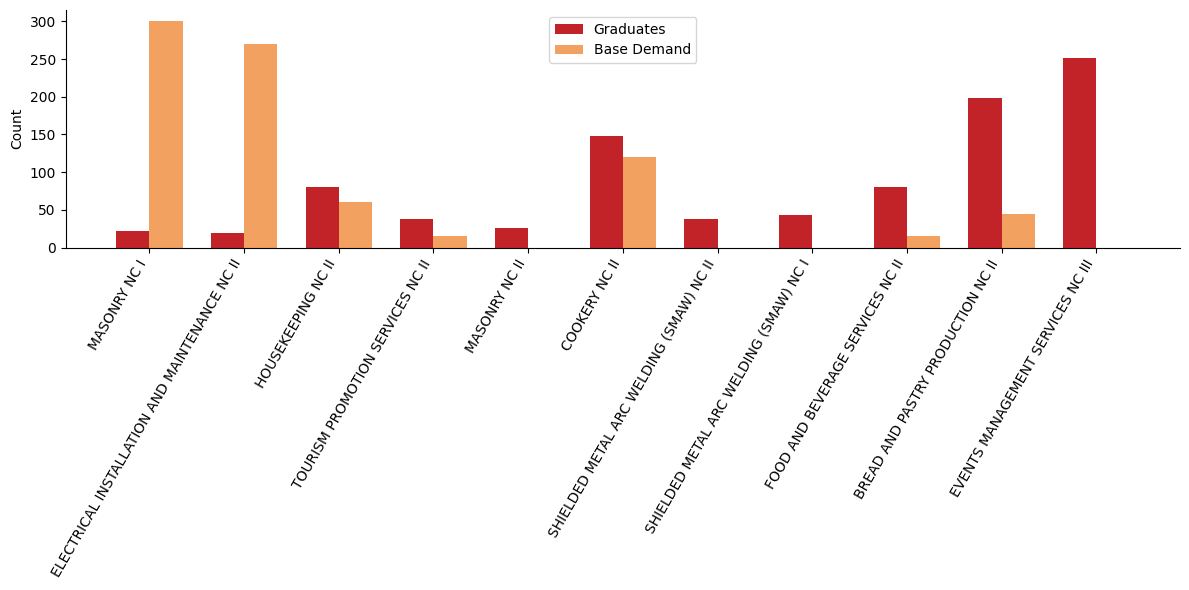

(<Figure size 1200x600 with 1 Axes>, <Axes: ylabel='Count'>)

In [169]:
plot_bohol_district_supply_demand_by_nc(
    df2_district,
    district="District 1",
    demand_col="Base_Expected_Total"
)

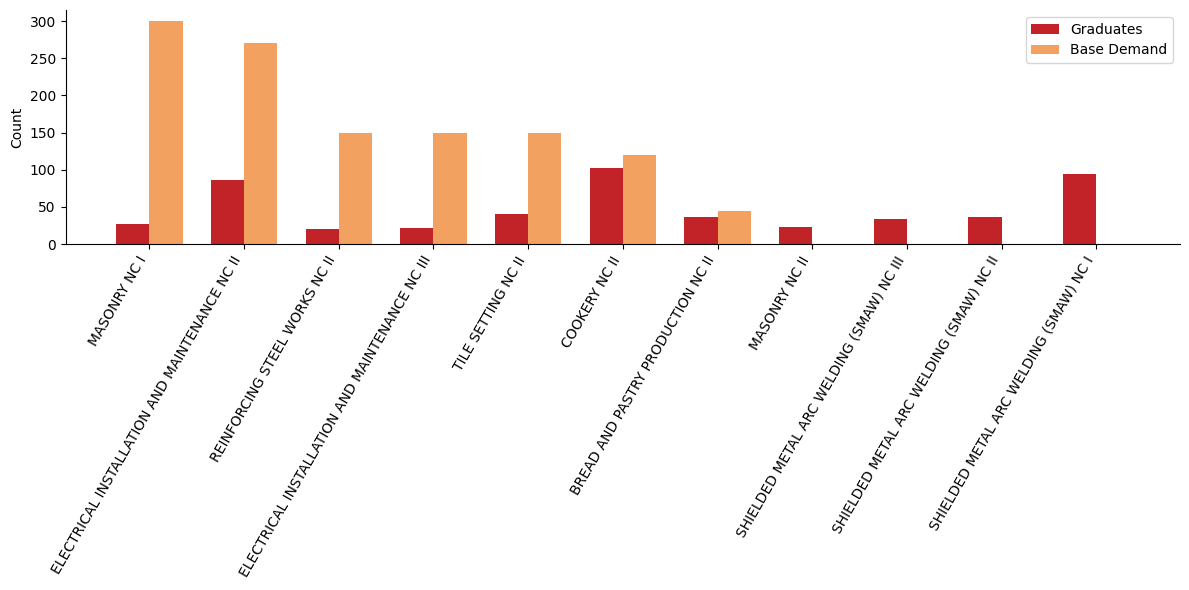

(<Figure size 1200x600 with 1 Axes>, <Axes: ylabel='Count'>)

In [170]:
plot_bohol_district_supply_demand_by_nc(
    df2_district,
    district="District 2",
    demand_col="Base_Expected_Total"
)

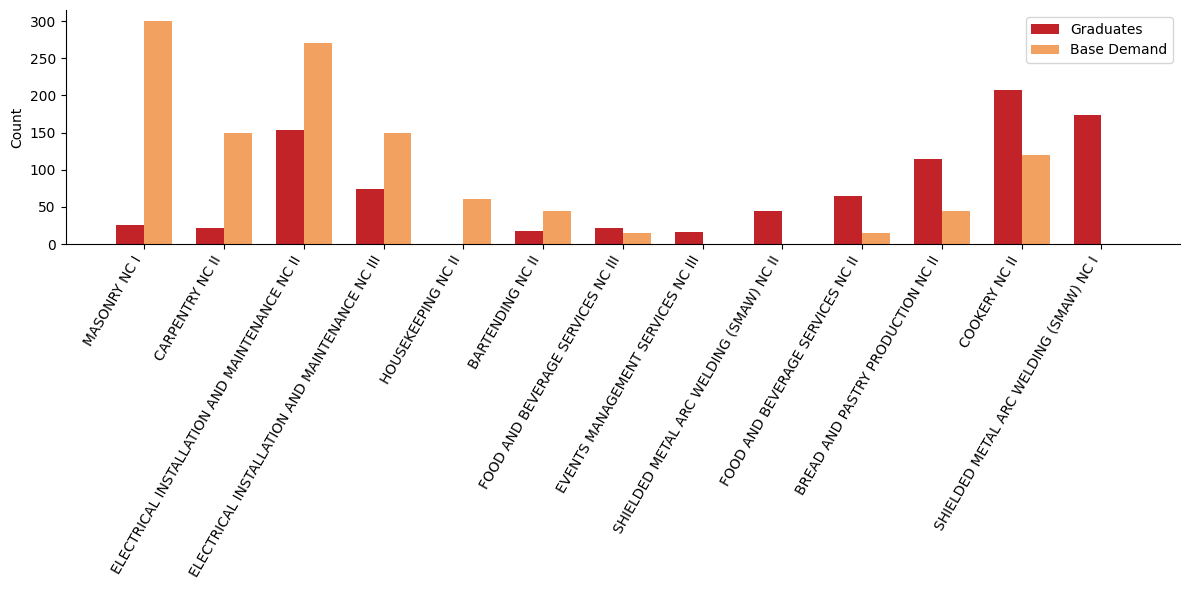

(<Figure size 1200x600 with 1 Axes>, <Axes: ylabel='Count'>)

In [171]:
plot_bohol_district_supply_demand_by_nc(
    df2_district,
    district="District 3",
    demand_col="Base_Expected_Total"
)